# Bayesian walk-forward : calibré vs non calibré (MCMC réel)

Compare, sur une saison de Ligue 1, le backtest chronologique du modèle
Bayesian brut et de la même pipeline avec `OutcomeCalibrator` (température +
biais 1X2 appris strictement sur les fenêtres passées, jamais sur la fenêtre
courante). Chaque fenêtre relance un fit MCMC (nutpie), donc les deux runs
coûtent environ deux fois un backtest Bayesian complet.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from footix.data_io.utils_scrapper import add_match_id, to_snake_case
from footix.evaluation import BacktestConfig, bayesian_spec, run_backtest
from footix.models.calibration import OutcomeCalibrator


In [2]:
DATA_FILE = Path('../data/FRA Ligue 1_2425.csv')
RUN = True

# Même protocole que model_performance_bayesian.ipynb, deux variantes de config.
config = BacktestConfig(
    bankroll=1_000.0,
    max_fraction=0.30,
    edge_floor=0.0,
    optimizer_iters=500,
    n_scenarios=10_000,
    markets=('1X2', 'O/U2.5'),
)
config_cal = BacktestConfig(
    bankroll=1_000.0,
    max_fraction=0.30,
    edge_floor=0.0,
    optimizer_iters=500,
    n_scenarios=10_000,
    markets=('1X2', 'O/U2.5'),
    # warmup=50 : les 50 premières fenêtres-matchs 1X2 restent non calibrées
    # (identité), le calibrateur n'apprend qu'après.
    calibrator_factory=lambda: OutcomeCalibrator(warmup=50),
)


In [3]:
if RUN:
    data = pd.read_csv(DATA_FILE)
    data.columns = [to_snake_case(column) for column in data.columns]
    data = add_match_id(data)
    n_teams = len(set(data['home_team']) | set(data['away_team']))

    specs = [bayesian_spec(n_goals=20, n_teams=n_teams, random_seed=42)]

    print('backtest brut (MCMC par fenêtre)...')
    result = run_backtest(data, specs, config)
    print('backtest calibré (MCMC par fenêtre)...')
    result_cal = run_backtest(data, specs, config_cal)
else:
    print('Set RUN = True after checking DATA_FILE.')


backtest brut (MCMC par fenêtre)...


NUTS[nutpie]: [home, intercept, tau_att, raw_atts, tau_def, raw_defs]


Output()

NUTS[nutpie]: [home, intercept, tau_att, raw_atts, tau_def, raw_defs]


Output()

...

Output()

NUTS[nutpie]: [home, intercept, tau_att, raw_atts, tau_def, raw_defs]


Output()

NUTS[nutpie]: [home, intercept, tau_att, raw_atts, tau_def, raw_defs]


Output()

In [4]:
if RUN:
    def summary(df):
        return (
            df.groupby(['model', 'market'])[['rps', 'log_loss', 'brier', 'accuracy']]
            .mean()
            .sort_index()
        )

    joined = pd.concat(
        {'brut': summary(result.predictions), 'calibre': summary(result_cal.predictions)},
        names=['variante'],
    ).swaplevel().sort_index()
    display(joined)

    delta = joined.loc['calibre'] - joined.loc['brut']
    display(delta.style.format('{:.4f}').set_caption(
        'Delta calibre - brut (negatif = meilleur pour rps/log_loss/brier)'
    ))


rps  log_loss     brier  accuracy
variante market model                                           
brut     1X2    bayesian  0.210561  0.985879  0.195275  0.545455
         O/U2.5 bayesian  0.261075  0.719287  0.261075  0.569024
calibre  1X2    bayesian  0.216105  0.999066  0.198633  0.511785
         O/U2.5 bayesian  0.261075  0.719287  0.261075  0.569024

,,rps,log_loss,brier,accuracy
market,model,,,,
1X2,bayesian,0.0055,0.0132,0.0034,-0.0337
O/U2.5,bayesian,0.0000,0.0000,0.0000,0.0000


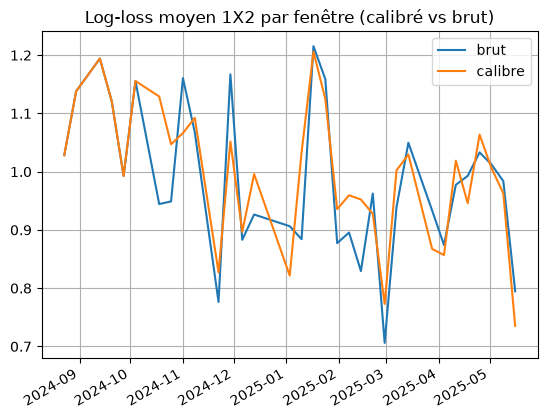

,brut,calibre
count,33.000000,33.000000
mean,0.985760,0.998725
std,0.128722,0.117913
min,0.706057,0.735251
25%,0.895468,0.935659
50%,0.977434,1.006352
75%,1.067634,1.066180
max,1.215396,1.205989


In [5]:
if RUN:
    x12 = result.predictions[result.predictions['market'] == '1X2']
    x12_cal = result_cal.predictions[result_cal.predictions['market'] == '1X2']

    # Log-loss moyen par fenêtre (1X2), calibré vs brut.
    def window_log_loss(df):
        rows = []
        for cutoff, group in df.groupby('cutoff'):
            losses = []
            for row in group.itertuples():
                probs = np.asarray(row.probabilities)
                losses.append(-np.log(probs[row.actual] + 1e-12))
            rows.append((cutoff, np.mean(losses)))
        return pd.Series(dict(rows), name='log_loss')

    window_ll = pd.DataFrame(
        {'brut': window_log_loss(x12), 'calibre': window_log_loss(x12_cal)}
    )
    window_ll.plot(title='Log-loss moyen 1X2 par fenêtre (calibré vs brut)')
    plt.grid()
    plt.show()
    display(window_ll.describe())


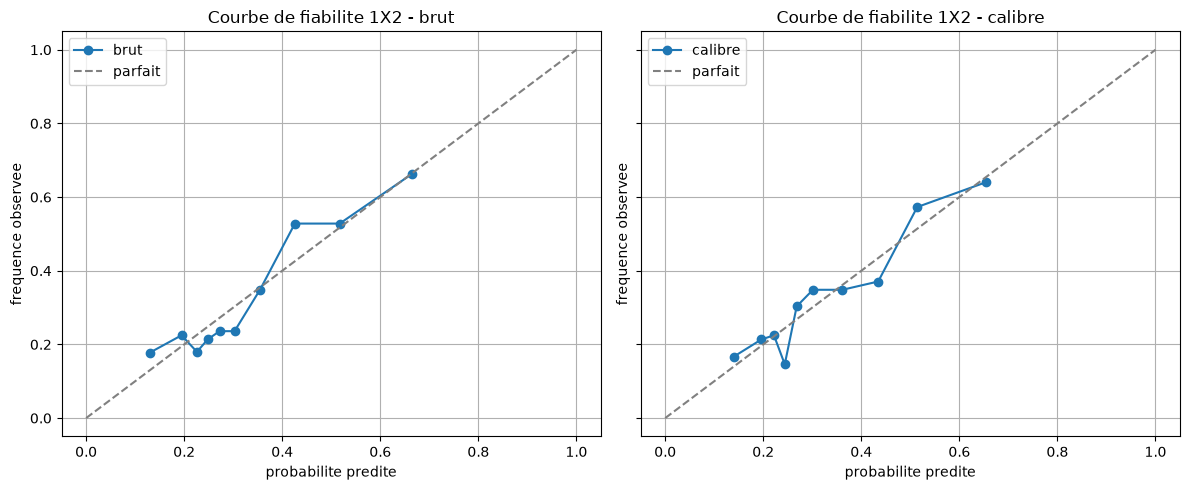

In [6]:
if RUN:
    def reliability(df, bins=10):
        rows = []
        for row in df.itertuples():
            probs = np.asarray(row.probabilities)
            for outcome, prob in enumerate(probs):
                rows.append((prob, float(row.actual == outcome)))
        frame = pd.DataFrame(rows, columns=['prob', 'realise'])
        frame['bin'] = pd.qcut(frame['prob'], bins, duplicates='drop')
        return frame.groupby('bin', observed=True).agg(
            predite=('prob', 'mean'), observee=('realise', 'mean'), n=('realise', 'size')
        )

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
    for ax, (name, df) in zip(
        axes, [('brut', x12), ('calibre', x12_cal)], strict=True
    ):
        rel = reliability(df)
        ax.plot(rel['predite'], rel['observee'], 'o-', label=name)
        ax.plot([0, 1], [0, 1], '--', color='grey', label='parfait')
        ax.set_xlabel('probabilite predite'); ax.set_ylabel('frequence observee')
        ax.set_title(f'Courbe de fiabilite 1X2 - {name}')
        ax.grid(); ax.legend()
    plt.tight_layout()
    plt.show()


In [7]:
if RUN:
    for name, r in [('brut', result), ('calibre', result_cal)]:
        display(r.windows.groupby('model')[['profit', 'total_stake', 'bankroll_after']].last())
        print(f'{name}: {len(r.bets)} paris')
        display(r.bets)


,profit,total_stake,bankroll_after
model,,,
bayesian,-331.5,1157.0,3541.1


brut: 29 paris


,model,cutoff,window_end,match_id,market,selection,odds,probability,edge,edge_std,stake,won,profit
0,bayesian,2024-08-30,2024-09-06,Lyon - Strasbourg - 2024-08-30,1X2,A,4.00,0.610063,1.440254,0.221193,298.0,False,-298.00
1,bayesian,2024-09-13,2024-09-20,Toulouse - Le Havre - 2024-09-15,1X2,A,4.50,0.547233,1.462550,0.199491,200.0,False,-200.00
2,bayesian,2024-09-13,2024-09-20,Paris SG - Brest - 2024-09-14,O/U2.5,O2.5,1.44,0.937768,0.350386,0.135574,9.0,True,3.96
3,bayesian,2024-10-04,2024-10-11,Nice - Paris SG - 2024-10-06,1X2,H,4.75,0.689973,2.277373,0.199714,151.0,False,-151.00
4,bayesian,2024-10-18,2024-10-25,Toulouse - Angers - 2024-10-20,1X2,A,6.50,0.364292,1.367895,0.143944,87.0,False,-87.00
5,bayesian,2024-10-25,2024-11-01,Lens - Lille - 2024-10-26,O/U2.5,U2.5,1.88,0.825668,0.552257,0.141113,80.0,True,70.40
6,bayesian,2024-11-08,2024-11-15,Nice - Lille - 2024-11-10,1X2,H,2.55,0.694235,0.770299,0.162723,101.0,False,-101.00
7,bayesian,2024-11-22,2024-11-29,Nice - Strasbourg - 2024-11-24,O/U2.5,O2.5,1.80,0.830606,0.495091,0.124322,58.0,True,46.40
8,bayesian,2024-11-22,2024-11-29,Auxerre - Angers - 2024-11-24,O/U2.5,O2.5,1.80,0.768832,0.383898,0.138075,13.0,False,-13.00
9,bayesian,2024-11-29,2024-12-06,Toulouse - Auxerre - 2024-12-01,1X2,A,5.25,0.369912,0.942039,0.131393,61.0,False,-61.00


,profit,total_stake,bankroll_after
model,,,
bayesian,-175.5,286.0,783.14


calibre: 62 paris


,model,cutoff,window_end,match_id,market,selection,odds,probability,edge,edge_std,stake,won,profit
0,bayesian,2024-08-30,2024-09-06,Lyon - Strasbourg - 2024-08-30,1X2,A,4.00,0.610063,1.440254,0.221193,298.0,False,-298.00
1,bayesian,2024-09-13,2024-09-20,Toulouse - Le Havre - 2024-09-15,1X2,A,4.50,0.547233,1.462550,0.199491,200.0,False,-200.00
2,bayesian,2024-09-13,2024-09-20,Paris SG - Brest - 2024-09-14,O/U2.5,O2.5,1.44,0.937768,0.350386,0.135574,9.0,True,3.96
3,bayesian,2024-10-04,2024-10-11,Nice - Paris SG - 2024-10-06,1X2,H,4.75,0.689973,2.277373,0.199714,151.0,False,-151.00
4,bayesian,2024-10-18,2024-10-25,St Etienne - Lens - 2024-10-19,1X2,H,5.25,0.414284,1.174989,0.077847,42.0,False,-42.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,bayesian,2025-05-09,2025-05-16,Toulouse - Lens - 2025-05-10,O/U2.5,U2.5,2.06,0.633560,0.305133,0.096035,27.0,True,28.62
58,bayesian,2025-05-16,2025-05-23,Paris SG - Auxerre - 2025-05-17,1X2,A,13.00,0.148165,0.926145,0.058113,39.0,False,-39.00
59,bayesian,2025-05-16,2025-05-23,Lens - Monaco - 2025-05-17,O/U2.5,U2.5,2.63,0.666898,0.753941,0.092350,184.0,False,-184.00
60,bayesian,2025-05-16,2025-05-23,Lille - Reims - 2025-05-17,1X2,A,8.50,0.194303,0.651571,0.062046,29.0,False,-29.00
